In [1]:
%load_ext autoreload
%autoreload 2
import os
#%set_env PROJ_LIB=/depot/dawson29/apps/condaenv/envs/cent7/5.1.0-py27/pyPIPS/share/proj
# %set_env LD_LIBRARY_PATH=/apps/cent7/intel/compilers_and_libraries_2017.1.132/linux/compiler/lib/intel64
# %set_env LIBRARY_PATH=/apps/cent7/intel/compilers_and_libraries_2017.1.132/linux/compiler/lib/intel64
#import pyCRMtools.modules.dualpara as dualpol
#import pyPIPS.dualpara as dualpol
import numpy as np
import math
import numpy.ma as ma
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as dates
from mpl_toolkits.axes_grid1 import ImageGrid,make_axes_locatable,host_subplot
from mpl_toolkits.basemap import Basemap
from datetime import datetime, timedelta
import pytz as pytz
import sys
import pyPIPS.utils as utils
import pyPIPS.thermolib as thermo
import pyPIPS.DSDlib as dsd
import pyPIPS.plotmodule as PIPSplot
import pyPIPS.simulator as sim
import pyPIPS.radarmodule as pyPIPSradar
import pyPIPS.PIPS as pips
import pyPIPS.pips_io as pips_io
import pyPIPS.parsivel_qc as pqc
import pyPIPS.parsivel_params as pp
from pyCRMtools.modules import plotmodule as plotmod
from pyCRMtools.modules import utils as CRMutils
from pyCRMtools.pycaps import arps_read
from pyCRMtools.pycaps import pycaps_fields
from pyCRMtools.pycaps import calvars_radar as radar
import pandas as pd
import xarray as xr
import glob
import numpy.random as random
from scipy.stats import gamma, uniform
from scipy.special import gamma as gammafunc
from scipy import ndimage
from metpy.plots import StationPlot
from metpy.calc import wind_components as get_wind_components
from metpy.cbook import get_test_data
from metpy.plots import StationPlot
from metpy.plots.wx_symbols import current_weather, sky_cover
from metpy.units import units
%matplotlib inline


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Read in nc files with PIPS data and ARPS model data interpolated to PIPS locations.
# PIPS data should be interpolated already to ARPS times in these files.

input_dir = '/depot/dawson29/data/Projects/VORTEXSE/simulations/ARPS/2017_IOP4C/EnKF/PIPS/deployment_time_length/nc/PIPS2A/CCN1000/'
#input_dir = '/Volumes/scr_fast/Projects/VORTEXSE/obsdata/full_PIPS_dataset/SATP_retr/ARPS_at_PIPS'
deployment_name = 'IOP4C_D1_2017'
input_file_paths = glob.glob(input_dir + '/*{}*nc'.format(deployment_name))
PIPS_ARPS_ds_list = []
for input_file in input_file_paths:
    PIPS_ARPS_ds_list.append(xr.open_dataset(input_file))


In [3]:
print(PIPS_ARPS_ds_list[0])

<xarray.Dataset>
Dimensions:                              (diameter_bin: 32, fallspeed_bin: 32, fields_KHTX: 49, member: 40, parameter: 3, time: 121)
Coordinates:
    min_diameter                         (diameter_bin) float64 ...
    max_diameter                         (diameter_bin) float64 ...
    diameter                             (diameter_bin) float64 ...
  * time                                 (time) datetime64[ns] 2017-04-30T20:00:00 ... 2017-04-30T22:00:00
  * diameter_bin                         (diameter_bin) float64 0.0625 ... 24.5
  * member                               (member) int64 1 2 3 4 ... 37 38 39 40
    xc                                   float64 ...
    yc                                   float64 ...
    xe                                   float64 ...
    ye                                   float64 ...
    PIPS                                 object ...
    fallspeed                            (fallspeed_bin) float64 ...
    min_fallspeeds               

In [4]:
import pyPIPS.polarimetric as pol
min_diameters = pp.parsivel_parameters['min_diameter_bins_mm']
mid_diameters = pp.parsivel_parameters['avg_diameter_bins_mm']
max_diameters = pp.parsivel_parameters['max_diameter_bins_mm']
mid_fallspeeds = pp.parsivel_parameters['avg_fallspeed_bins_mps']
wavelength = 10.7
scatt_file = '/home/cbelak/pyPIPS/tmatrix/S-Band/SCTT_RAIN_fw100.dat'
bin_width = pp.parsivel_parameters['max_diameter_bins_mm'] - pp.parsivel_parameters['min_diameter_bins_mm']
plotdir = '/depot/dawson29/data/Projects/VORTEXSE/simulations/ARPS/2017_IOP4C/EnKF/PIPS/deployment_time_length/plots/PIPS2A/CCN100/meteograms/'
#plotdir = '/Volumes/scr_fast/Projects/VORTEXSE/obsdata/full_PIPS_dataset/SATP_retr/plots/ARPS_at_PIPS'
meteogram_plotdir = os.path.join(plotdir, 'conv_meteograms')
if not os.path.exists(meteogram_plotdir):
    os.makedirs(meteogram_plotdir)

In [5]:
# Plot observed DSD meteograms interpolated to model times
# Get PSD times valid at the model times

PSD_datetimes_model = pips.get_PSD_datetimes(PIPS_ARPS_ds_list[0], dim_name='time')
PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

# Prepare axis parameters
# We'll use the model times for the boundaries of the x-axis
timelimits = [PSDstarttimes[0], PSDstarttimes[-1]]
diamlimits = [0.0, 9.0]
diamytick = 1.0
DSDtype = 'observed'
locator = dates.MinuteLocator(byminute=[0,15,30,45])
minorlocator = dates.MinuteLocator(byminute=range(0,60,5))
dateformat = '%H:%M'
formatter = dates.DateFormatter(dateformat)

axparams = {'majorxlocator': locator, 'majorxformatter': formatter,
            'minorxlocator': minorlocator,
            'axeslimits': [timelimits, diamlimits],
            'majorylocator': ticker.MultipleLocator(base=diamytick),
            'axeslabels': [None, 'D (mm)']}

# Ok, now we should have everything ready to go to plot the meteograms.
# Let'er rip!
for PIPS_ARPS_ds in PIPS_ARPS_ds_list:
    ND = PIPS_ARPS_ds['ND_qc']
    logND = np.log10(ND)
    D0 = dsd.calc_D0_bin(ND) * 1000. # Get to mm
    dualpol_PIPS = pol.calpolrain(wavelength, scatt_file, ND, bin_width)
    dBZ = dualpol_PIPS['REF']
    ZDR = dualpol_PIPS['ZDR']
    
    disvars = {'min_diameter': min_diameters, 'PSDstarttimes': PSDstarttimes,
               'PSDmidtimes': PSDmidtimes, 'logND': logND.T, 'D_0': D0, 'REF': dBZ, 'ZDR': ZDR}
    
#     dis_plot_name = PIPS_ARPS_ds.probe_name + '_interp_to_model_' + DSDtype
#     PIPSplot.plotDSDmeteograms(dis_plot_name, meteogram_plotdir, axparams, disvars, close_fig=False)

/home/cbelak/.conda/envs/cent7/5.1.0-py27/pyPIPS/lib/python3.7/site-packages/xarray/core/computation.py:601: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/home/cbelak/.conda/envs/cent7/5.1.0-py27/pyPIPS/lib/python3.7/site-packages/xarray/core/computation.py:601: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


In [6]:
# Create a combined DataArray for all the ensemble members and then convert to a DataFrame for use in seaborn
PIPS_time_range = {
    'PIPS2A': [datetime(2017, 4, 30, 20, 15), datetime(2017, 4, 30, 22, 0)]
}

PIPS_names = [PIPS_ARPS_ds.probe_name for PIPS_ARPS_ds in PIPS_ARPS_ds_list]
PIPS_to_plot = 'PIPS2A'
PIPS_to_plot_index = PIPS_names.index(PIPS_to_plot)

# D0_raw_model_list = []
# for PIPS_ARPS_ds in PIPS_ARPS_ds_list:
#     D0_raw_model_list.append(dsd.calc_D0_bin(PIPS_ARPS_ds['ND']) * 1000.)
# D0_raw_model_combined = xr.concat(D0_raw_model_list, xr.DataArray(PIPS_names, dims='PIPS'))
# print(D0_raw_model_combined)
ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['p']
D0_raw_model_combined = ND / 100 
D0_raw_model_combined_df = D0_raw_model_combined.to_dataframe(name='p')

PT = PIPS_ARPS_ds_list[PIPS_to_plot_index]['pt']
# print(PT)
# D0_raw_model_combined = PT 
D0_raw_model_combined_df['pt'] = np.array(PT).reshape(121*40)#D0_raw_model_combined.to_dataframe(name='pt')

U = PIPS_ARPS_ds_list[PIPS_to_plot_index]['u']
# print(PT)
D0_raw_model_combined_df['u'] = np.array(U).reshape(121*40)#D0_raw_model_combined.to_dataframe(name='pt')

V = PIPS_ARPS_ds_list[PIPS_to_plot_index]['v']
# print(PT)
D0_raw_model_combined_df['v'] = np.array(V).reshape(121*40)#D0_raw_model_combined.to_dataframe(name='pt')

windspeed= np.sqrt(D0_raw_model_combined_df['u']**2+D0_raw_model_combined_df['v']**2)
winddirection=180.+180/math.pi*np.arctan2(D0_raw_model_combined_df['u'],D0_raw_model_combined_df['v'])
D0_raw_model_combined_df['windspeed']=windspeed
D0_raw_model_combined_df['winddirection']=winddirection
print(D0_raw_model_combined_df)
# # D0
# D0_raw_model_list = [D0_raw_model_dict[PIPS_to_plot].reset_coords(drop=True) 
#                             for D0_raw_model_dict in D0_raw_model_dict_list]
# D0_raw_model_combined = xr.concat(D0_raw_model_list, dim='member')
# D0_raw_model_combined_df = D0_raw_model_combined.to_dataframe(name='D0')


# # Reflectivity

# dBZ_raw_model_list = [dBZ_raw_model_dict[PIPS_to_plot].reset_coords(drop=True) 
#                             for dBZ_raw_model_dict in dBZ_raw_model_dict_list]
# dBZ_raw_model_combined = xr.concat(dBZ_raw_model_list, dim='member')
# dBZ_raw_model_combined_df = dBZ_raw_model_combined.to_dataframe(name='dBZ')

# # ZDR

# ZDR_raw_model_list = [dualpol_raw_model_dict[PIPS_to_plot]['ZDR'].reset_coords(drop=True) 
#                             for dualpol_raw_model_dict in dualpol_raw_model_dict_list]
# ZDR_raw_model_combined = xr.concat(ZDR_raw_model_list, dim='member')
# ZDR_raw_model_combined_df = ZDR_raw_model_combined.to_dataframe(name='ZDR')

                                       xc             yc             xe  \
member time                                                               
1      2017-04-30 20:00:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 20:01:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 20:02:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 20:03:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 20:04:00  196597.956186  120587.232005  196597.956186   
...                                   ...            ...            ...   
40     2017-04-30 21:56:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 21:57:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 21:58:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 21:59:00  196597.956186  120587.232005  196597.956186   
       2017-04-30 22:00:00  196597.956186  120587.232005  196597.956186   

                        

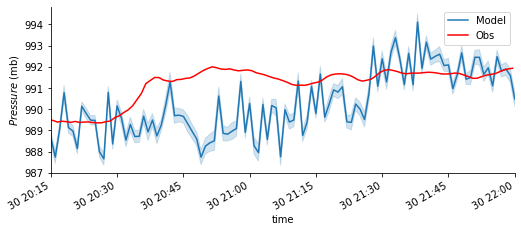

In [7]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['pressure']
D0_obs = ND # Get to mm
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
g = sns.relplot(x="time", y="p", kind="line", ci="sd", data=D0_raw_model_combined_df_test, label='Model')
g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Pressure$ (mb)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])

figname = '{}_model_obs_pressure_original.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

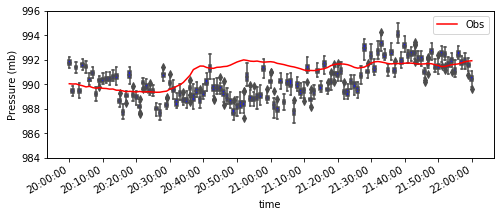

In [8]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['pressure']
D0_obs = ND 

D0_obs_df = D0_obs.to_dataframe(name='D0_obs')
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
fig, ax = plt.subplots(figsize=(8,3))
# Create a new axes object "ax2" that is a twin of ax
ax2 = ax.twinx()
#g = sns.boxplot(x="time", y="D0",data=D0_raw_model_combined_df_test, ax=ax)
#g.fig.set_size_inches(8., 3., forward = True)
ax.set_ylabel(r'$D_0$ (mm)')
#D0_obs_df.reset_index(inplace=True)
#sns.lineplot(x="time", y="D0", data=D0_raw_model_combined_df_test, label='Model', ax=ax)
#sns.lineplot(x="time", y="D0_obs", data=D0_obs_df, label='Obs', ax=ax)
sns.boxplot(x="time", y="p",data=D0_raw_model_combined_df_test, ax=ax, color='blue')
# Plot the observation line plot on ax2 instead of ax, and give it a simple range of indices
# from 0 to the length of the D0_obs_df Dataframe, that is, the number of times.
ax2.plot(np.arange(len(D0_obs_df)), D0_obs_df['D0_obs'].values, label='Obs', color='red')
plt.legend(loc='best')

# Code snippet from https://stackoverflow.com/questions/53528054/
# the-most-elegant-way-to-modify-messy-and-overlapping-date-labels-below-x-axis

# set the frequency for labelling the xaxis
freq = int(10)
# set the xlabels as the datetime data for the given labelling frequency,
# also use only the date for the label
ax.set_xticklabels(D0_raw_model_combined_df_test.iloc[::freq].time.dt.time)
# set the xticks at the same frequency as the xlabels
xtix = ax.get_xticks()
ax.set_xticks(xtix[::freq])
# nicer label format for dates
fig.autofmt_xdate()

# Set the two axes to have the same y-range. Very important!
ax.set_ylim(984., 996.0)
ax2.set_ylim(984., 996.0)

ax.set_ylabel('Pressure (mb)')
# Turns of the y ticks and labels for the right side of the graph that would otherwise be placed there
plt.tick_params(axis='y', which='both', right=False, labelright=False)

figname = '{}_model_obs_pressure_box_new_2.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

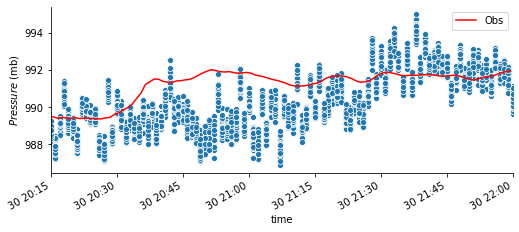

In [9]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns
import matplotlib.colors 
from matplotlib.colors import LogNorm

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['pressure']
D0_obs = ND 
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)

palette = sns.cubehelix_palette(light=0.7,n_colors=6)
g = sns.relplot(x="time", y="p",data=D0_raw_model_combined_df_test)

#g.ax.plot(time, D0, 'b', kind="line", data=D0_raw_model_combined_df_test, label="Model")

g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Pressure$ (mb)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])
#g._legend.remove()

figname = '{}_model_obs_pressure_spread.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')


In [10]:
obs_sensor_temp = PIPS_ARPS_ds_list[PIPS_to_plot_index]['fasttemp'] + 273.15
print(PIPS_ARPS_ds_list[PIPS_to_plot_index]['fasttemp'])
obs_pressure = PIPS_ARPS_ds_list[PIPS_to_plot_index]['pressure'] 

obs_pt = obs_sensor_temp * (1000/obs_pressure)**(0.286)
print(obs_pt)

<xarray.DataArray 'fasttemp' (time: 121)>
array([26.996742, 26.862258, 26.856733, 26.809175, 26.8567  , 26.9423  ,
       26.865283, 26.856408, 26.940558, 26.842875, 26.838767, 26.815717,
       26.877833, 26.757033, 26.675608, 26.764133, 26.752692, 26.877392,
       26.776333, 26.623417, 26.654458, 26.625942, 26.724558, 26.621058,
       26.573375, 26.637825, 26.569292, 26.435983, 26.468275, 26.711792,
       26.641692, 26.669317, 26.673692, 26.825833, 26.885133, 26.853475,
       26.840425, 25.959817, 23.822708, 22.544325, 20.855483, 20.399146,
       20.357973, 20.3543  , 20.163375, 20.07385 , 19.971817, 20.038708,
       20.014158, 19.90405 , 20.060625, 20.118408, 20.087592, 19.975   ,
       19.821442, 19.659133, 19.603975, 19.591683, 19.599558, 19.531125,
       19.478417, 19.4125  , 19.374175, 19.315808, 19.310142, 19.2587  ,
       19.201533, 19.1822  , 19.112458, 19.0455  , 19.092992, 19.064158,
       19.098283, 19.104125, 19.13695 , 19.1393  , 19.153108, 19.188825,
       19

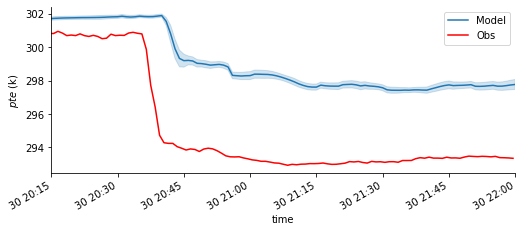

In [11]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

D0_obs = obs_pt # Get to mm
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
g = sns.relplot(x="time", y="pt", kind="line", ci="sd", data=D0_raw_model_combined_df_test, label='Model')
g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$pte$ (k)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])

figname = '{}_model_obs_pte_original.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

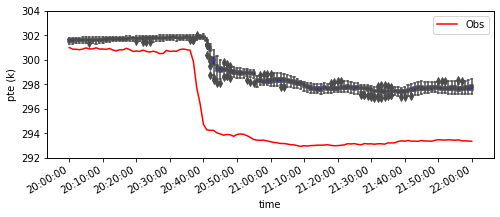

In [12]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

D0_obs = obs_pt

D0_obs_df = D0_obs.to_dataframe(name='D0_obs')
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
fig, ax = plt.subplots(figsize=(8,3))
# Create a new axes object "ax2" that is a twin of ax
ax2 = ax.twinx()
#g = sns.boxplot(x="time", y="D0",data=D0_raw_model_combined_df_test, ax=ax)
#g.fig.set_size_inches(8., 3., forward = True)
ax.set_ylabel(r'$D_0$ (mm)')
#D0_obs_df.reset_index(inplace=True)
#sns.lineplot(x="time", y="D0", data=D0_raw_model_combined_df_test, label='Model', ax=ax)
#sns.lineplot(x="time", y="D0_obs", data=D0_obs_df, label='Obs', ax=ax)
sns.boxplot(x="time", y="pt",data=D0_raw_model_combined_df_test, ax=ax, color='blue')
# Plot the observation line plot on ax2 instead of ax, and give it a simple range of indices
# from 0 to the length of the D0_obs_df Dataframe, that is, the number of times.
ax2.plot(np.arange(len(D0_obs_df)), D0_obs_df['D0_obs'].values, label='Obs', color='red')
plt.legend(loc='best')

# Code snippet from https://stackoverflow.com/questions/53528054/
# the-most-elegant-way-to-modify-messy-and-overlapping-date-labels-below-x-axis

# set the frequency for labelling the xaxis
freq = int(10)
# set the xlabels as the datetime data for the given labelling frequency,
# also use only the date for the label
ax.set_xticklabels(D0_raw_model_combined_df_test.iloc[::freq].time.dt.time)
# set the xticks at the same frequency as the xlabels
xtix = ax.get_xticks()
ax.set_xticks(xtix[::freq])
# nicer label format for dates
fig.autofmt_xdate()

# Set the two axes to have the same y-range. Very important!
ax.set_ylim(292., 304.)
ax2.set_ylim(292., 304.)

ax.set_ylabel('pte (k)')
# Turns of the y ticks and labels for the right side of the graph that would otherwise be placed there
plt.tick_params(axis='y', which='both', right=False, labelright=False)

figname = '{}_model_obs_pte_box_new_2.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

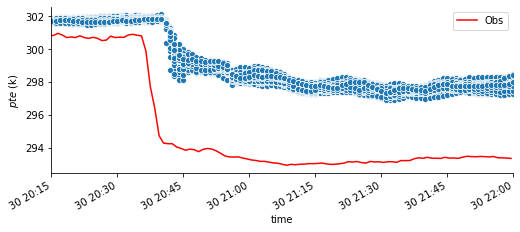

In [13]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns
import matplotlib.colors 
from matplotlib.colors import LogNorm

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

D0_obs = obs_pt
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)

palette = sns.cubehelix_palette(light=0.7,n_colors=6)
g = sns.relplot(x="time", y="pt",data=D0_raw_model_combined_df_test)

#g.ax.plot(time, D0, 'b', kind="line", data=D0_raw_model_combined_df_test, label="Model")

g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$pte$ (k)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])
#g._legend.remove()

figname = '{}_model_obs_pte_spread.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')


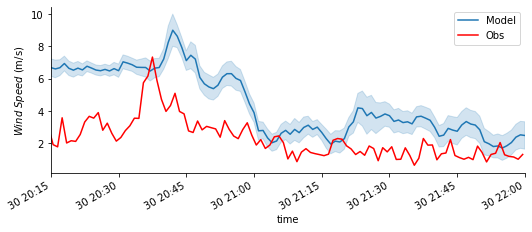

In [14]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['windspd']
D0_obs = ND # Get to mm
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
g = sns.relplot(x="time", y="windspeed", kind="line", ci="sd", data=D0_raw_model_combined_df_test, label='Model')
g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Wind$ $Speed$ (m/s)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])

figname = '{}_model_obs_windspeed_original.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

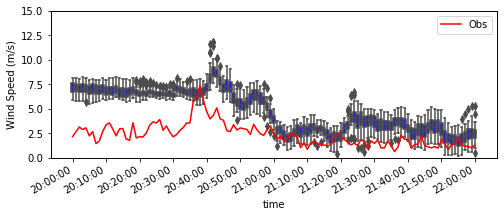

In [15]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['windspd']
D0_obs = ND 

D0_obs_df = D0_obs.to_dataframe(name='D0_obs')
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
fig, ax = plt.subplots(figsize=(8,3))
# Create a new axes object "ax2" that is a twin of ax
ax2 = ax.twinx()
#g = sns.boxplot(x="time", y="D0",data=D0_raw_model_combined_df_test, ax=ax)
#g.fig.set_size_inches(8., 3., forward = True)
ax.set_ylabel(r'$D_0$ (mm)')
#D0_obs_df.reset_index(inplace=True)
#sns.lineplot(x="time", y="D0", data=D0_raw_model_combined_df_test, label='Model', ax=ax)
#sns.lineplot(x="time", y="D0_obs", data=D0_obs_df, label='Obs', ax=ax)
sns.boxplot(x="time", y="windspeed",data=D0_raw_model_combined_df_test, ax=ax, color='blue')
# Plot the observation line plot on ax2 instead of ax, and give it a simple range of indices
# from 0 to the length of the D0_obs_df Dataframe, that is, the number of times.
ax2.plot(np.arange(len(D0_obs_df)), D0_obs_df['D0_obs'].values, label='Obs', color='red')
plt.legend(loc='best')

# Code snippet from https://stackoverflow.com/questions/53528054/
# the-most-elegant-way-to-modify-messy-and-overlapping-date-labels-below-x-axis

# set the frequency for labelling the xaxis
freq = int(10)
# set the xlabels as the datetime data for the given labelling frequency,
# also use only the date for the label
ax.set_xticklabels(D0_raw_model_combined_df_test.iloc[::freq].time.dt.time)
# set the xticks at the same frequency as the xlabels
xtix = ax.get_xticks()
ax.set_xticks(xtix[::freq])
# nicer label format for dates
fig.autofmt_xdate()

# Set the two axes to have the same y-range. Very important!
ax.set_ylim(0., 15.0)
ax2.set_ylim(0., 15.0)

ax.set_ylabel('Wind Speed (m/s)')
# Turns of the y ticks and labels for the right side of the graph that would otherwise be placed there
plt.tick_params(axis='y', which='both', right=False, labelright=False)

figname = '{}_model_obs_windspeed_box_new_2.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

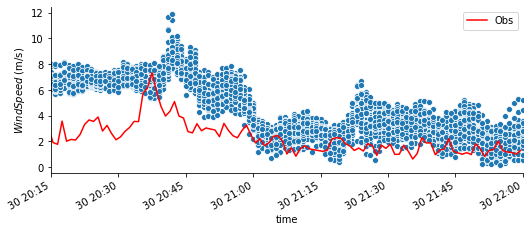

In [16]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns
import matplotlib.colors 
from matplotlib.colors import LogNorm

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['windspd']
D0_obs = ND 
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)

palette = sns.cubehelix_palette(light=0.7,n_colors=6)
g = sns.relplot(x="time", y="windspeed",data=D0_raw_model_combined_df_test)

#g.ax.plot(time, D0, 'b', kind="line", data=D0_raw_model_combined_df_test, label="Model")

g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Wind Speed$ (m/s)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])
#g._legend.remove()

figname = '{}_model_obs_windspeed_spread.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')


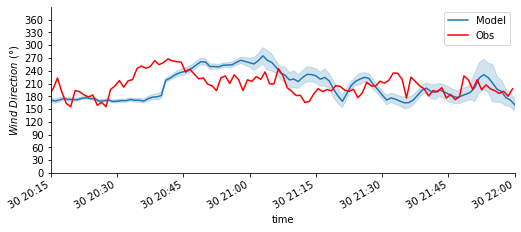

In [17]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['winddirabs']
D0_obs = ND # Get to mm
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
g = sns.relplot(x="time", y="winddirection", kind="line", ci="sd", data=D0_raw_model_combined_df_test, label='Model')
g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Wind$ $Direction$ (°)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])
g.ax.set_ylim(0,390)
g.ax.yaxis.set_ticks(np.arange(0, 390, 30))


figname = '{}_model_obs_wind_dir_original.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

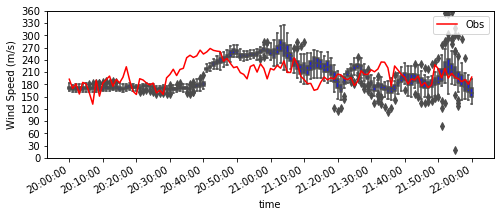

In [18]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['winddirabs']
D0_obs = ND 

D0_obs_df = D0_obs.to_dataframe(name='D0_obs')
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)
fig, ax = plt.subplots(figsize=(8,3))
# Create a new axes object "ax2" that is a twin of ax
ax2 = ax.twinx()
#g = sns.boxplot(x="time", y="D0",data=D0_raw_model_combined_df_test, ax=ax)
#g.fig.set_size_inches(8., 3., forward = True)
ax.set_ylabel(r'$D_0$ (mm)')
#D0_obs_df.reset_index(inplace=True)
#sns.lineplot(x="time", y="D0", data=D0_raw_model_combined_df_test, label='Model', ax=ax)
#sns.lineplot(x="time", y="D0_obs", data=D0_obs_df, label='Obs', ax=ax)
sns.boxplot(x="time", y="winddirection",data=D0_raw_model_combined_df_test, ax=ax, color='blue')
# Plot the observation line plot on ax2 instead of ax, and give it a simple range of indices
# from 0 to the length of the D0_obs_df Dataframe, that is, the number of times.
ax2.plot(np.arange(len(D0_obs_df)), D0_obs_df['D0_obs'].values, label='Obs', color='red')
plt.legend(loc='best')

# Code snippet from https://stackoverflow.com/questions/53528054/
# the-most-elegant-way-to-modify-messy-and-overlapping-date-labels-below-x-axis

# set the frequency for labelling the xaxis
freq = int(10)
# set the xlabels as the datetime data for the given labelling frequency,
# also use only the date for the label
ax.set_xticklabels(D0_raw_model_combined_df_test.iloc[::freq].time.dt.time)
# set the xticks at the same frequency as the xlabels
xtix = ax.get_xticks()
ax.set_xticks(xtix[::freq])
# nicer label format for dates
fig.autofmt_xdate()

# Set the two axes to have the same y-range. Very important!
ax.set_ylim(0., 360.0)
ax2.set_ylim(0., 360.0)
start = 0 
end = 390
ax.yaxis.set_ticks(np.arange(start, end, 30))

ax.set_ylabel('Wind Speed (m/s)')
# Turns of the y ticks and labels for the right side of the graph that would otherwise be placed there
plt.tick_params(axis='y', which='both', right=False, labelright=False)

figname = '{}_model_obs_wind_dir_box_new_2.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')

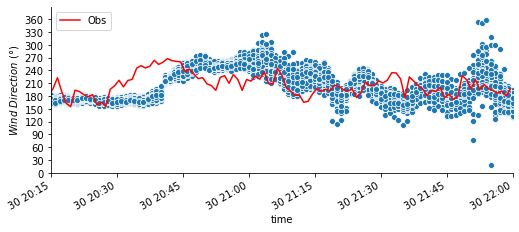

In [19]:
# Plot a timeseries of D0 with confidence intervals from the model ensemble
import seaborn as sns
import matplotlib.colors 
from matplotlib.colors import LogNorm

#PSD_datetimes_model = pips.get_PSD_datetimes(var_ds, dim_name='time')
#PSD_datetimes_model_dict = pips.get_PSD_time_bins(PSD_datetimes_model)
#PSDstarttimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_edges'])
#PSDmidtimes = dates.date2num(PSD_datetimes_model_dict['PSD_datetimes_centers'])

ND = PIPS_ARPS_ds_list[PIPS_to_plot_index]['winddirabs']
D0_obs = ND 
D0_raw_model_combined_df_test = D0_raw_model_combined_df.copy()
D0_raw_model_combined_df_test.reset_index(inplace=True)

palette = sns.cubehelix_palette(light=0.7,n_colors=6)
g = sns.relplot(x="time", y="winddirection",data=D0_raw_model_combined_df_test)

#g.ax.plot(time, D0, 'b', kind="line", data=D0_raw_model_combined_df_test, label="Model")

g.fig.set_size_inches(8., 3., forward = True)
g.fig.autofmt_xdate()
g.set_ylabels(r'$Wind$ $Direction$ (°)')
g.ax.plot(PSDmidtimes, D0_obs, 'r', label='Obs')
plt.legend(loc='best')
g.ax.set_xlim(PIPS_time_range[PIPS_to_plot])
g.ax.set_ylim(0,390)
g.ax.yaxis.set_ticks(np.arange(0, 390, 30))
#g._legend.remove()

figname = '{}_model_obs_wind_dir_spread.png'.format(PIPS_to_plot)
figpath = os.path.join(meteogram_plotdir, figname)
plt.savefig(figpath, dpi=300, bbox_inches='tight')


In [20]:
# D0_raw_model_combined_df_test['D0']
# D0_obs
cc_combined = []
bias_combined = []
abs_bias_combined = []

for member in range(1,40+1):
    member -= 1
#     print(D0_raw_model_combined_df_test['D0'][0+61*member:61+61*member])
#     print(D0_obs)
    cc = pd.DataFrame({'mod':D0_raw_model_combined_df_test['D0'][0+61*member:61+61*member],'obs':D0_obs}).corr().iloc[0,1]
#     print(cc)
    bias = np.nansum(D0_raw_model_combined_df_test['D0'][0+61*member:61+61*member]-D0_obs) / D0_obs.isnull().count()
#     print(D0_obs.isnull().count())
#     print(bias)
    abs_bias = np.nansum(abs(D0_raw_model_combined_df_test['D0'][0+61*member:61+61*member]-D0_obs)) / D0_obs.isnull().count()

    bias_combined.append(bias)
    abs_bias_combined.append(abs_bias)
    cc_combined.append(cc)
bias_avg=np.mean(bias_combined)
abs_bias_avg=np.mean(abs_bias_combined)
cc_avg=np.mean(cc_combined)
print(bias_avg)
print(cc_avg)
print(abs_bias_avg)

KeyError: 'D0'

In [26]:
#print(D0_raw_model_combined_df_test)
#D0_obs_pydatetime = D0_obs_df.set_index('time').index.to_pydatetime()
#print(D0_obs_pydatetime)
#print(PSDmidtimes)